## 1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.models as models
from torchvision.models import VGG16_Weights
from torchvision import transforms

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from medmnist import PathMNIST, INFO

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

## 2. Class Names

In [2]:
info = INFO['pathmnist']
info_dict = info['label']

# Convert label dictionary to sorted list of class names
class_names = [info_dict[key] for key in sorted(info_dict.keys())]
num_classes = len(class_names)  # ✅ FIX: no hardcoded magic number

for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

print(f"\nTotal classes: {num_classes}")

0: adipose
1: background
2: debris
3: lymphocytes
4: mucus
5: smooth muscle
6: normal colon mucosa
7: cancer-associated stroma
8: colorectal adenocarcinoma epithelium

Total classes: 9


## 3. Transforms

**Fixes applied:**
- Removed `Grayscale` — PathMNIST is already RGB, not grayscale
- Standard VGG preprocessing: `Resize(256)` → `CenterCrop(224)` matches ImageNet training
- Separate transforms for train (with augmentation) vs val/test (clean)

In [3]:
# ✅ FIX: train transform includes augmentation
transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),          # standard VGG preprocessing
    transforms.RandomHorizontalFlip(),   # augmentation
    transforms.RandomVerticalFlip(),     # augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ✅ FIX: val/test transform — no augmentation, same resize strategy
transform_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

## 4. Dataset Download

In [4]:
# ✅ FIX: each split uses the appropriate transform
train_dataset = PathMNIST(split="train", download=True, transform=transform_train)
val_dataset   = PathMNIST(split="val",   download=True, transform=transform_val)
test_dataset  = PathMNIST(split="test",  download=True, transform=transform_val)

Using downloaded and verified file: /home/yousifcreates/.medmnist/pathmnist.npz
Using downloaded and verified file: /home/yousifcreates/.medmnist/pathmnist.npz
Using downloaded and verified file: /home/yousifcreates/.medmnist/pathmnist.npz


## 5. Inspect a Sample

In [5]:
img, label = train_dataset[5]

# ✅ FIX: img.shape (not img.size which returns the bound method)
print(f"Image type:  {type(img)}")
print(f"Image shape: {img.shape}")
print(f"Label type:  {type(label)}, Label value: {label}")

Image type:  <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label type:  <class 'numpy.ndarray'>, Label value: [8]


/tmp/ipykernel_4337/2060732500.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {label} ({class_names[int(label)]})")


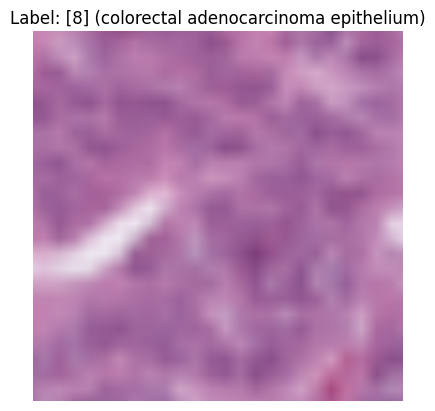

In [6]:
# ✅ FIX: denormalize before imshow to avoid clipping warning
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

img_display = (img * std[:, None, None] + mean[:, None, None]).clamp(0, 1)

plt.imshow(img_display.permute(1, 2, 0))
plt.title(f"Label: {label} ({class_names[int(label)]})") 
plt.axis('off')
plt.show()

## 6. Device

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 7. DataLoaders

In [8]:
# ✅ FIX: added num_workers=4 to avoid CPU bottlenecking GPU
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                              pin_memory=True, num_workers=4)
val_dataloader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                              pin_memory=True, num_workers=4)
test_dataloader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                              pin_memory=True, num_workers=4)

## 8. Model Setup

**Fixes applied:**
- Removed duplicate VGG16 load (was loaded in two separate cells)
- Replaced deprecated `pretrained=True` with `weights=VGG16_Weights.IMAGENET1K_V1`
- Unfreezes last conv block (`features[-3:]`) for partial fine-tuning
- Uses `num_classes` instead of hardcoded `9`

In [9]:
# ✅ FIX: load once, use updated weights API
vgg16 = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

# Freeze all feature extractor layers
for param in vgg16.features.parameters():
    param.requires_grad = False

# ✅ FIX: partially unfreeze — last conv block for fine-tuning
# features[-3:] = Conv2d(512,512) → ReLU → MaxPool
for param in vgg16.features[-3:].parameters():
    param.requires_grad = True

# ✅ FIX: use num_classes variable, not hardcoded 9
vgg16.classifier[6] = nn.Linear(4096, num_classes)

vgg16 = vgg16.to(device)

print(vgg16)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## 9. Hyperparameters, Loss, Optimizer & Scheduler

In [11]:
learning_rate = 0.0001
epochs        = 10

criterion = nn.CrossEntropyLoss()

# ✅ FIX: optimizer covers ALL unfrozen parameters (features[-3:] + classifier)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16.parameters()),
    lr=learning_rate
)

# ✅ NEW: cosine LR decay over all epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

## 10. Training Loop

**Fixes applied:**
- `loss.backward()` — added parentheses (was `loss.backward`, a no-op)
- `vgg16.train()` called at start and re-set each epoch
- Per-epoch validation accuracy tracked
- Best model saved based on validation accuracy
- Average epoch loss reported (not just last batch)
- `scheduler.step()` called after each epoch

In [13]:
best_val_acc = 0.0

for epoch in range(epochs):

    # ✅ FIX: explicitly set train mode each epoch (activates Dropout)
    vgg16.train()
    total_epoch_loss = 0

    for X, y in train_dataloader:

        y = y.squeeze().long()
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = vgg16(X)
        loss    = criterion(outputs, y)

        # ✅ FIX: loss.backward() — parentheses are essential!
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

    # Step the LR scheduler after each epoch
    scheduler.step()

    # ✅ NEW: validation pass every epoch
    vgg16.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for X, y in val_dataloader:
            y = y.squeeze().long().to(device)
            X = X.to(device)
            _, predicted = torch.max(vgg16(X), 1)
            val_total   += y.size(0)
            val_correct += (predicted == y).sum().item()

    val_acc   = val_correct / val_total
    avg_loss  = total_epoch_loss / len(train_dataloader)

    # ✅ NEW: save best model checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(vgg16.state_dict(), "best_model.pth")

    print(f"Epoch {epoch:02d} | Avg Loss: {avg_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | Best Val Acc: {best_val_acc:.4f}")

Epoch 00 | Avg Loss: 0.3896 | Val Acc: 0.8916 | Best Val Acc: 0.8916
Epoch 01 | Avg Loss: 0.2730 | Val Acc: 0.9090 | Best Val Acc: 0.9090
Epoch 02 | Avg Loss: 0.2209 | Val Acc: 0.9185 | Best Val Acc: 0.9185
Epoch 03 | Avg Loss: 0.1847 | Val Acc: 0.9197 | Best Val Acc: 0.9197
Epoch 04 | Avg Loss: 0.1531 | Val Acc: 0.9266 | Best Val Acc: 0.9266
Epoch 05 | Avg Loss: 0.1265 | Val Acc: 0.9313 | Best Val Acc: 0.9313
Epoch 06 | Avg Loss: 0.0999 | Val Acc: 0.9339 | Best Val Acc: 0.9339


KeyboardInterrupt: 

## 11. Evaluation

**Fixes applied:**
- Loads best checkpoint (not last epoch weights)
- Refactored 3× repeated loops into a single `evaluate()` function
- Reports per-class precision, recall, F1 + confusion matrix heatmap

In [ ]:
# ✅ FIX: load best saved weights before evaluating
vgg16.load_state_dict(torch.load("best_model.pth"))

# ✅ FIX: single reusable evaluation function (was copy-pasted 3 times)
def evaluate(model, dataloader, device, split_name=""):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in dataloader:
            y = y.squeeze().long().to(device)
            X = X.to(device)
            _, predicted = torch.max(model(X), 1)
            all_preds.extend(predicted.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    print(f"\n{'='*60}")
    print(f"{split_name} Accuracy: {acc:.4f}")
    print(f"{'='*60}")

    # ✅ NEW: per-class precision, recall, F1
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # ✅ NEW: confusion matrix heatmap
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names,
                cmap='Blues')
    plt.title(f"{split_name} Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
evaluate(vgg16, test_dataloader,  device, "Test")

In [ ]:
# ✅ FIX: typo fixed ('valdidation' → 'validation')
evaluate(vgg16, val_dataloader,   device, "Validation")

In [ ]:
evaluate(vgg16, train_dataloader, device, "Train")